In [2]:

import ioniq.core as ct
from ioniq.parsers import SpeedyStatSplit
from ioniq.parsers import AutoSquareParser
import ioniq.datatypes as dt
from ioniq.parsers import SpikeParser
import os
import pandas as pd
import numpy as np
from concurrent.futures import ThreadPoolExecutor
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from ioniq.utils import Trimmer, Filter##, extract_features

## Load pickle file that has extracted events. 

In [ ]:
masterdf=pd.read_pickle("<path/to/pickled/eventDF>") #trans-to-cis contains 10nM

## Let's filter for events that are between 10 ms and 45 ms with a mean fractional greater than 0.82. 

In [15]:
example_set=masterdf.loc[(masterdf["duration"]>0.01)&
                         (masterdf["duration"]<0.045)&
                         (masterdf["frac"]>0.82)]


example_set=example_set.reset_index()

## Let's randomly select and plot 10 events at -200 mV, -250 mV, and -300 mV.

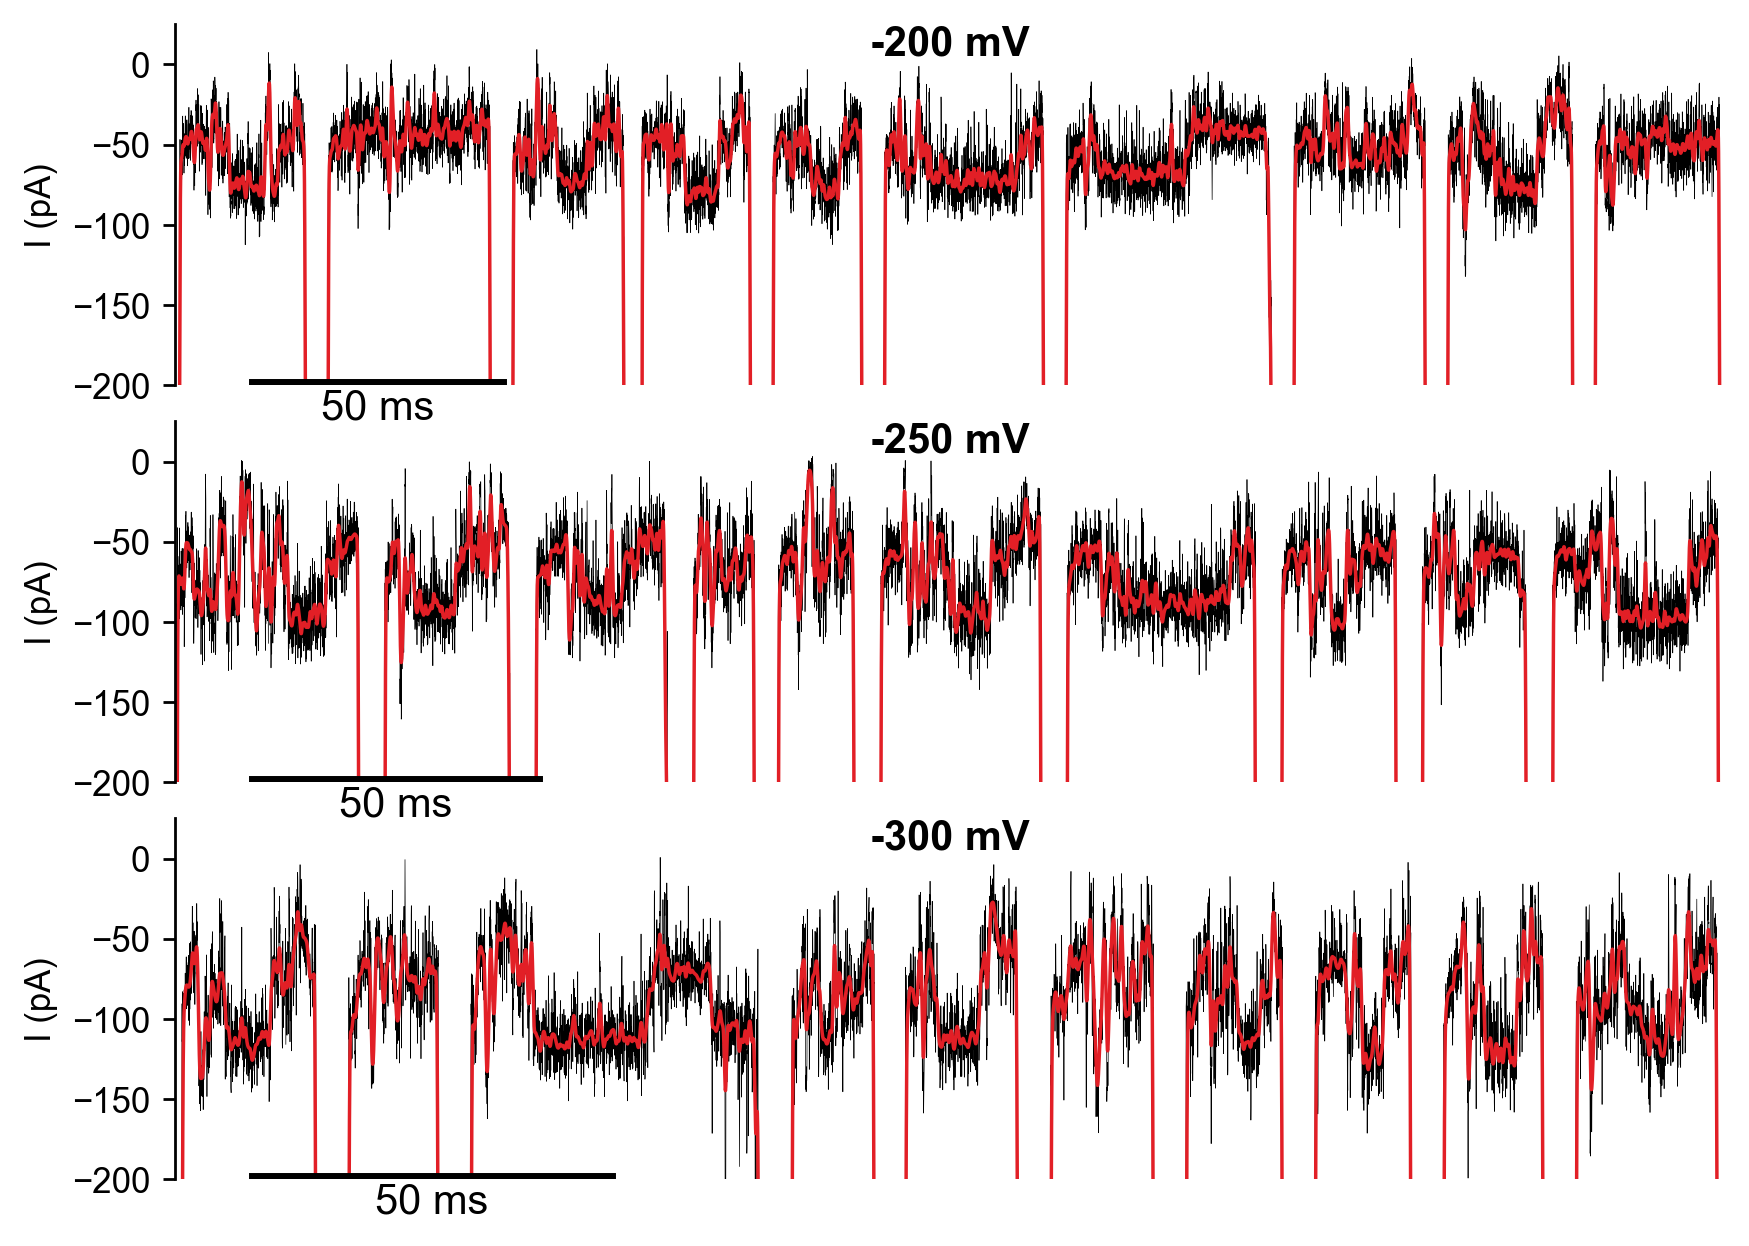

In [19]:
import matplotlib.gridspec as gridspec
import matplotlib as mpl
import warnings

mpl.rcParams["svg.fonttype"] = "none"
# Set Arial as the global font
plt.rcParams['font.family'] = 'Arial'
example_set=example_set.loc[(example_set["sample_type"] == "MBP_D10")]
random_state=20 
filtered_color = "#E21F26"  # red
randomset = pd.concat([
    example_set[example_set["Voltage"] == -200].sample(10, random_state=random_state),
    example_set[example_set["Voltage"] == -250].sample(10, random_state=random_state),
    example_set[example_set["Voltage"] == -300].sample(10, random_state=random_state),
])

# Set filter parameters (1.5 kHz) to overlay on original signal (25 kHz) 
cutoff_frequency = 1500
filter_type = "lowpass"
filter_method = "bessel"
order = 8
bidirectional = True
sampling_frequency = 50000

filt = Filter(
    cutoff_frequency=cutoff_frequency,
    filter_type='lowpass',
    filter_method=filter_method,
    order=order,
    bidirectional=bidirectional,
    sampling_frequency=sampling_frequency
)

fig = plt.figure(figsize=(8, 6), dpi=250)
gs = gridspec.GridSpec(3, 1, height_ratios=[1,1,1], hspace=0.1)

voltages = [-200, -250, -300]
gap = 0.0025

for row, volt in enumerate(voltages):
    ax = fig.add_subplot(gs[row])
    t_offset = 0

    subset = randomset[randomset["Voltage"] == volt]
    for idx, (_, rowd) in enumerate(subset.iterrows()):
        current = rowd["wrap"] * -1000
        filtered = current.copy()
        filt(filtered)

        tt = np.arange(len(current)) / 50000 + t_offset

        # rasterized signal
        ax.plot(tt, current, c='k', lw=0.2, rasterized=True, clip_on=True)
        ax.plot(tt, filtered, c=filtered_color, lw=1, rasterized=True, clip_on=True)

        t_offset = tt[-1] + gap

    ax.set_ylim(-200, 25)
    ax.set_xlim(0, tt[-1])

    # 50 pA y‐ticks
    ax.set_yticks(np.arange(-200, 26, 50))
    ax.set_ylabel(f"I (pA)", fontsize=10)

    # annotate voltage inside
    ax.text(0.5, 1, f"{volt} mV",
            transform=ax.transAxes,
            ha='center', va='top',
            fontsize=12, fontweight='bold')

    # no x‐axis
    sns.despine(ax=ax, left=False, bottom=True)
    ax.xaxis.set_visible(False)

    total_time = ax.get_xlim()[1] - ax.get_xlim()[0]
    frac_len = 0.050 / total_time
    y_frac = 0.01  # 5% above bottom
    ax.plot([0.05, 0.05+frac_len], [y_frac, y_frac],
            transform=ax.transAxes, c='k', lw=2)
    ax.text(0.05+frac_len/2, y_frac - 0.02, "50 ms",
            transform=ax.transAxes, ha='center', va='top', fontsize=12)

# plt.tight_layout()


## Next, let's look at the statistics for the fractional blockade versus dwell time of all extracted MBP-D10 reverse transport events as a function of voltage.

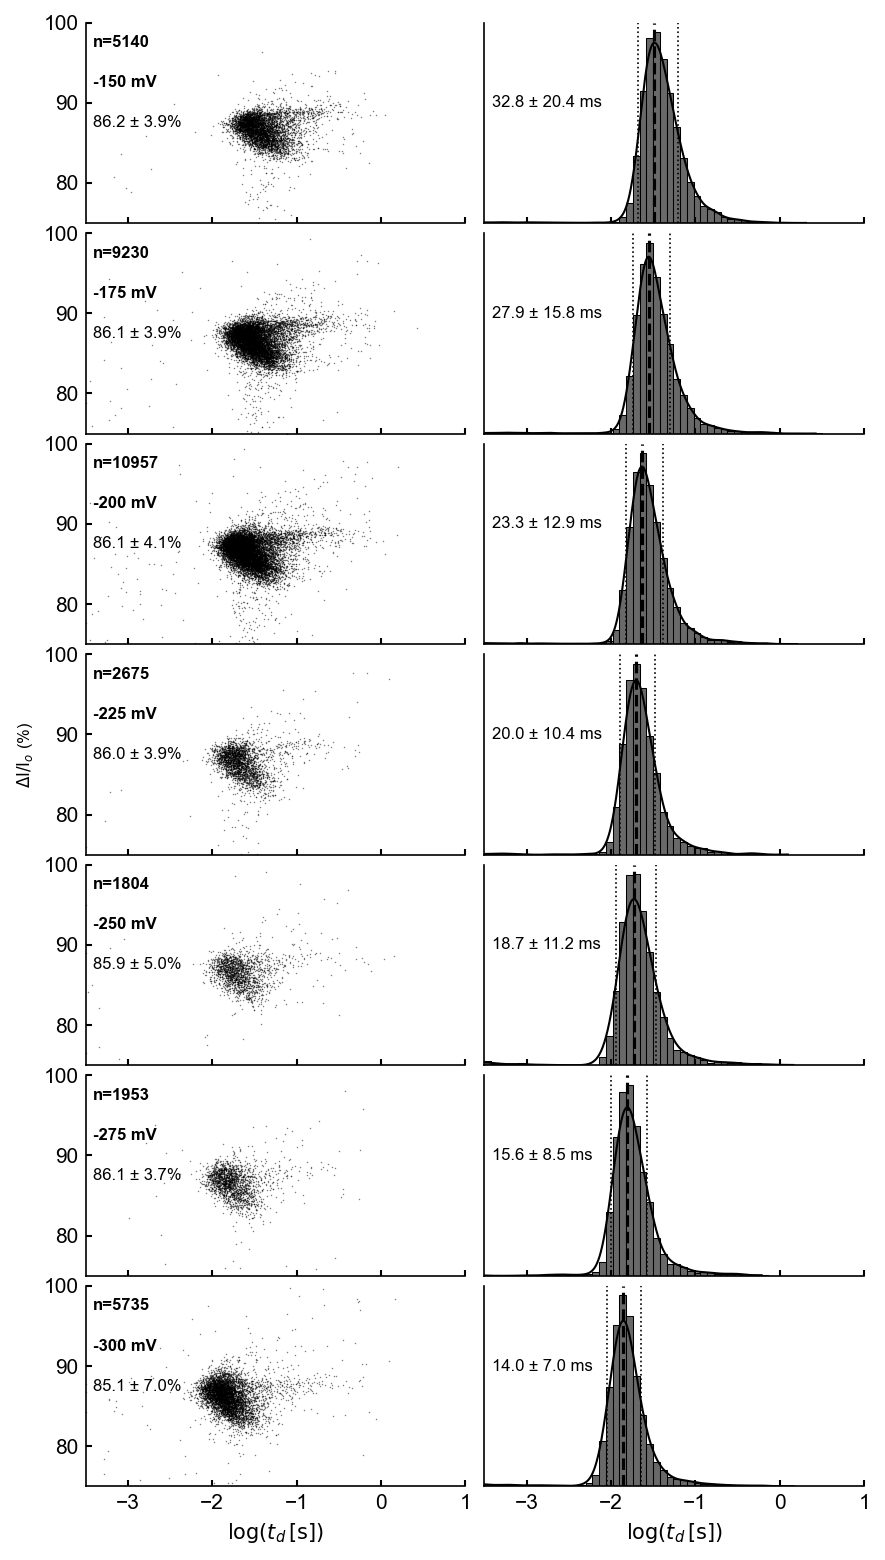

In [ ]:
%matplotlib inline
# %matplotlib qt
import matplotlib as mpl
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

plt.close('all')
hueorder = [-150, -175, -200, -225, -250, -275, -300] #selected voltages to analyze
hueorder = list(map(str, hueorder))
mpl.rcParams['svg.fonttype'] = 'none'
plt.rcParams["pdf.use14corefonts"] = False
mpl.rcParams["font.family"] = ["Arial"]
plt.rcParams["ps.useafm"] = True
plt.rcParams["figure.dpi"] = 150

n_rows = len(hueorder)

for groupname, df in masterdf.groupby("sample_type"):
    df["fracpct"] = np.multiply(df["frac"], 100)
    df["voltagestr"] = df["Voltage"].astype(str)
    df = df[np.isfinite(df["log_duration"])]

    fig, axes = plt.subplots(
        n_rows, 2,
        figsize=(6, 1.5 * n_rows),  # square aspect ratio per row
        gridspec_kw={'width_ratios': [1, 1]},  # equal width columns
        sharex=True
    )

    binrange = [-3.5, 1]
    ##binrange = [-5, 1]
    binwidth = 0.08
    ##binwidth = 0.05
    palette_s = sns.color_palette(["k"] * n_rows)
    palette_h = sns.color_palette(["dimgray"] * n_rows)

    for i, volt in enumerate(hueorder):
        subdf = df[df["voltagestr"] == volt]
        
        # Left panel: log-scale scatter plot; fractional blockade versus dwell time
        ax_left = axes[i, 0]
        sns.scatterplot(data=subdf, x="log_duration", y="fracpct",
                        s=0.5, alpha=0.5, rasterized=True, linewidth=0,
                        color=palette_s[i], ax=ax_left)
        ax_left.set_ylim(75, 100)
        ax_left.set_xlim(binrange)
        ax_left.tick_params(axis='both', direction='in', length=3, width=0.7)
        ax_left.set_ylabel(r"$\Delta \mathrm{I} / \mathrm{I}_o$ (%)" if i == n_rows // 2 else "", fontsize=8)
        if i == n_rows - 1:
            ax_left.set_xlabel(r"$\log(t_d\,[\mathrm{s}])$", fontsize=10)
        else:
            ax_left.set_xlabel("")
        # Label sample size and voltage on left
        sample_size = len(subdf["log_duration"])
        ax_left.text(0.02, 0.90, f"n={sample_size}", fontweight="bold", color=palette_s[i],
                     ha="left", va="center", transform=ax_left.transAxes, fontsize=8)
        ax_left.text(0.02, 0.70, f"{volt} mV", fontweight="bold", color=palette_s[i],
                     ha="left", va="center", transform=ax_left.transAxes, fontsize=8)
        ax_left.tick_params(axis='both', direction='in', length=3, width=1)  # inward ticks

        # Right panel: log-scale dwell time histogram
        ax_right = axes[i, 1]
        sns.histplot(data=subdf, x="log_duration",
                     binwidth=binwidth, binrange=binrange, clip_on=True,
                     fill=True, alpha=1, linewidth=0.5, edgecolor="black",
                     common_norm=True, stat="density", color=palette_h[i],
                     ax=ax_right)
        ax_right.set_xlim(binrange)
        ax_right.set_yticks([])
        ax_right.set_ylabel("")
        ax_right.tick_params(axis='both', direction='in', length=3, width=1)
        if i == n_rows - 1:
            ax_right.set_xlabel(r"$\log(t_d\,[\mathrm{s}])$", fontsize=10)
        else:
            ax_right.set_xlabel("")

        # Remove top and right borders and ensure inward ticks
        for ax in [ax_left, ax_right]:
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

        # KDE-based geometric mean and FWHM
        log_durations = subdf["log_duration"].values
        kde = gaussian_kde(log_durations)
        x_grid = np.linspace(log_durations.min(), log_durations.max(), 1000)
        kde_vals = kde(x_grid)
        
        # Bandwidth (scalar, since 1D)
        h = np.sqrt(kde.covariance[0, 0])
        # print(f"{volt}: Bandwidth h:", h)
        # print(f"{volt}: Bandwidth h:", (10 ** h) * 1000)  # ms
        # print(f"{volt}: standard dev.:", np.std(log_durations))

        half_max = np.max(kde_vals) / 2
        above_half = kde_vals >= half_max
        crossing_indices = np.where(np.diff(above_half.astype(int)))[0]
        if len(crossing_indices) >= 2:
            x0 = x_grid[crossing_indices[0]]
            x1 = x_grid[crossing_indices[-1]]
            fwhm_log = x1 - x0
            fwhm_lin_ms = (10 ** x1 - 10 ** x0) * 1000  # ms
            fwhm_half = fwhm_lin_ms / 2

             # FWHM visualization: vertical dashed lines
            ax_right.axvline(x0, color="black", linestyle=":", linewidth=0.8)
            ax_right.axvline(x1, color="black", linestyle=":", linewidth=0.8)

        else:
            fwhm_log = np.nan
            fwhm_lin_ms = np.nan

        log_mean = np.mean(log_durations)
        geo_mean_ms = 10 ** log_mean * 1000

        # Find mode (peak) of the KDE
        peak_idx = np.argmax(kde_vals)
        log_mode = x_grid[peak_idx]
        geo_peak_ms = 10 ** log_mode * 1000

        # Plot KDE curve over histogram
        ax_right.plot(x_grid, kde_vals, color="black", linewidth=1)
        # Plot vertical dashed line at the log-scaled mean
        ax_right.axvline(log_mode, color="black", linestyle="--", linewidth=1.5)
      
        # Blockade stats
        fracpct = subdf["fracpct"].values
        frac_mean = np.mean(fracpct)
        frac_std = np.std(fracpct)

      
        # Annotate scatter (right)
        ax_right.text(0.02, 0.60, f"{geo_peak_ms:.1f} ± {fwhm_half:.1f} ms", transform=ax_right.transAxes,
              fontsize=8, ha='left', va='center')
    
        # Annotate scatter (left)
        ax_left.text(0.02, 0.50, f"{frac_mean:.1f} ± {frac_std:.1f}%", transform=ax_left.transAxes,
                     fontsize=8, ha='left', va='center')
        

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.05, wspace=0.05)
